Import all the required modules

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX

Clean and process the data. Prepare the time series for modelling on average time spent in the mall by a vehicle entering on a particular day

In [37]:
# Load the dataset
data = pd.read_csv('parkingLot.csv')

# Step 1: Clean the dataset
# Convert 'timestamp' to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Remove duplicates
data.drop_duplicates(inplace=True)

# Step 2: Filter out entries between 12 AM and 5 AM for both cameras
data = data[(data['timestamp'].dt.hour >= 5) & (data['timestamp'].dt.hour < 24)]

# Step 3: Add a date column for grouping
data['date'] = data['timestamp'].dt.date

# Step 4: Separate entry and exit data
entry_data = data[data['camera_id'] == 1].rename(columns={'date': 'date_entry'})
exit_data = data[data['camera_id'] == 2].rename(columns={'date': 'date_exit'})


# Step 5: Merge entry and exit data on vehicle number and date
merged_data = entry_data.merge(exit_data, 
                                left_on=['vehicle_no', 'date_entry'], 
                                right_on=['vehicle_no', 'date_exit'], 
                                suffixes=('_entry', '_exit'))


# Step 5: Merge entry and exit data on vehicle number and respective dates
merged_data = entry_data.merge(exit_data, 
                                left_on=['vehicle_no', 'date_entry'], 
                                right_on=['vehicle_no', 'date_exit'], 
                                suffixes=('_entry', '_exit'))


# Step 6: Calculate the time spent in the mall
merged_data['time_spent'] = (merged_data['timestamp_exit'] - merged_data['timestamp_entry']).dt.total_seconds() / 60.0  # Convert to minutes

# Step 7: Group by date and calculate the average time spent
average_time_spent = merged_data.groupby('date_entry')['time_spent'].mean().reset_index()

# Ensure the 'date' column is in datetime format for time series analysis
average_time_spent['date_entry'] = pd.to_datetime(average_time_spent['date_entry'])

# print(average_time_spent)


Split the given data into train and test sets

In [38]:
# Split the data into train and test sets
train_size = len(average_time_spent) - 7
train, test = average_time_spent[:train_size], average_time_spent[train_size:]

# Check the sizes of train and test sets
print(f"\nTrain set size: {len(train)}, Test set size: {len(test)}")
# print(test)


Train set size: 56, Test set size: 7


Based on the plot of the given time series we have observed strong seasonality with time period of about 10 days and no(0) trend. \
The given time series turned out to be almost stationary.(Check the plot in the next few cells). We have hence gone with d = 0 and found p=4 and q=4 by observing ACF and PACF(to get an idea about the degree of correlation) as well as through experimentation(try to decrease MASE).

In [39]:
# SARIMAX model with seasonal parameters based on your observations
sarima_model = SARIMAX(train['time_spent'], 
                       order=(4, 0, 4),              # Non-seasonal parameters
                       seasonal_order=(1, 0, 1, 10),  # Seasonal parameters with a period of 10 days
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

# Fit the model
sarima_results = sarima_model.fit()

# Forecast the next 14 days
forecast_values = sarima_results.get_forecast(steps=7)
forecast = forecast_values.predicted_mean

# print("\nForecast for the average time spent by a person the next 14 days(49 to 62):")
# print(forecast)

# # Example of fitting the ARIMA model with tuned parameters
# p = 1  # Adjust based on PACF
# d = 0  # Adjust based on differencing results
# q = 0  # Adjust based on ACF

# model = ARIMA(train['time_spent'], order=(p, d, q))
# model_fit = model.fit()

# # Forecast for the next 7 days
# forecast = model_fit.forecast(steps=7)

Let us calculate the value of MAPE and MASE on our test part of the given data. \
SARIMA Model : [ MAPE: 0.0062, MASE: 0.0921 ] according to our model

In [40]:
# Calculate MAE for the ARIMA model predictions
mae_model = mean_absolute_error(test['time_spent'], forecast)

# Calculate MAPE
mape_arima = mean_absolute_percentage_error(test['time_spent'], forecast)

# Calculate the naive forecast using the last observation method
naive_forecast = test['time_spent'].shift(1)  # Shift to simulate naive forecasting
# Skip the first NaN value in MAE calculation
mae_naive = mean_absolute_error(test['time_spent'][1:], naive_forecast[1:])  

# #Alternatively, if you want to use the mean of the training set as a naive forecast
# naive_forecast_mean = train['total_entries'].mean()
# naive_forecast_values = [naive_forecast_mean] * len(test)
# mae_naive = mean_absolute_error(test['total_entries'], naive_forecast_values)

# Calculate MASE
mase_arima = mae_model / mae_naive

# Print the results
print(f"SARIMA Model : [ MAPE: {mape_arima:.4f}, MASE: {mase_arima:.4f} ]")

SARIMA Model : [ MAPE: 0.0062, MASE: 0.0921 ]


We have decided on the seasonality of 10 days from the graph below. As you can see the graph has no apparent trend but has a repetitive pattern of ups and downs with a period of 10 days that suggest we use a SARIMA model

In [41]:
# Assuming 'train' is your training dataset with 'date' and 'total_entries' columns
plt.figure(figsize=(12, 6))

# Plotting the total entries over time
plt.plot(train['date_entry'], train['time_spent'], marker='o', linestyle='-', color='blue', markersize=3)

# Adding titles and labels
plt.title('Average time spent by a person today(min)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Entries', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)

plt.tight_layout()
plt.savefig('plot20.png')
plt.close()

Lets plot ACF and PACF. From the graph we can see a strong correlation for lags from 1 to 3/4 in PACF. We chose p = 4 in SARIMA and we similarly set q = 4 for least MASE

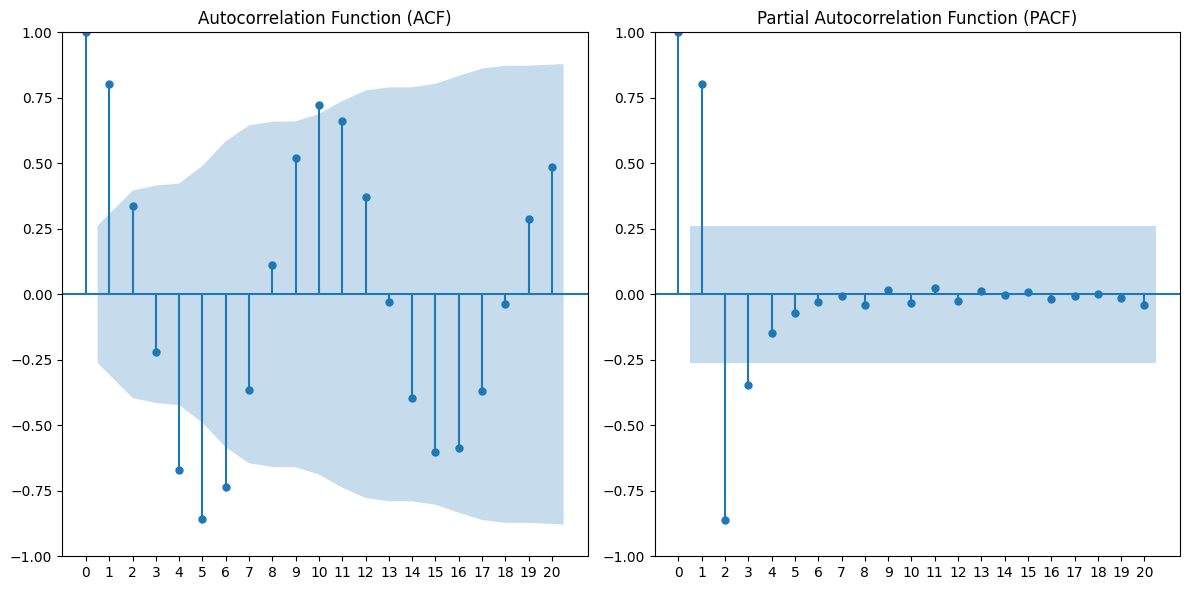

In [42]:
# Assuming 'train' is your training dataset with the 'total_entries' column
plt.figure(figsize=(12, 6))

# ACF Plot
plt.subplot(1, 2, 1)
plot_acf(train['time_spent'], lags=20, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')
plt.xticks(range(0, 21, 1))  # Set xticks to show every lag up to 20

# PACF Plot
plt.subplot(1, 2, 2)
plot_pacf(train['time_spent'], lags=20, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')
plt.xticks(range(0, 21, 1))  # Set xticks to show every lag up to 20

plt.tight_layout()
plt.show()


Now that we have verified the accuracy of our SARIMA MODEL. Lets predict the next average time spent per person in the mall for the next 7 days.

In [43]:
# SARIMAX model with seasonal parameters based on your observations
sarima_model_final = SARIMAX(average_time_spent['time_spent'], 
                       order=(4, 0, 4),              # Non-seasonal parameters
                       seasonal_order=(1, 0, 1, 10),  # Seasonal parameters with a period of 10 days
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

# Fit the model
sarima_results_final = sarima_model_final.fit(method='powell')

# Forecast the next 14 days
forecast_values_final = sarima_results_final.get_forecast(steps=7)
forecast_final = forecast_values_final.predicted_mean

# Print the final forecasted values 
print(forecast_final)

Optimization terminated successfully.
         Current function value: 1.544080
         Iterations: 11
         Function evaluations: 1213
63    339.567819
64    360.657282
65    368.624311
66    362.162941
67    343.220077
68    319.990320
69    301.078917
Name: predicted_mean, dtype: float64
